# GPU random-walk Monte Carlo for spectral dimension on cage-like lattices

This notebook:

1. Either **loads** a graph from an edge list file `tiled600_edgelist.txt` (if present),
   or **generates** a large synthetic 12-regular graph as a stand-in for a tiled cage lattice.
2. Runs many random walks in parallel on the GPU.
3. Estimates the return probability $P(t)$.
4. Fits $P(t) \sim t^{-d_s/2}$ to extract the spectral dimension $d_s$.

Once you have a true tiled 600-cell cage lattice edge list, just drop it in as `tiled600_edgelist.txt`
and the notebook will automatically use it instead of the synthetic graph.

In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 1. Graph source: real tiled lattice if available, otherwise synthetic 12-regular graph

The notebook first checks for `tiled600_edgelist.txt` in the current directory.

- If it exists: we load it as the graph.
- If it does **not** exist: we generate a large synthetic 12-regular graph (same degree as 600-cell vertices)
  using a simple configuration-model style construction.

Later, when you have a true tiled 600-cell cage lattice edge list, just place it as
`tiled600_edgelist.txt` next to this notebook and rerun.

In [4]:
EDGE_LIST_PATH = Path('tiled600_edgelist.txt')

def generate_synthetic_12_regular_graph(num_vertices, degree=12, seed=1234):
    """Generate a simple synthetic d-regular graph using a configuration-model style pairing.
    This is not guaranteed to be simple (may have multi-edges), but is fine for random-walk statistics.
    """
    rng = np.random.default_rng(seed)
    stubs = np.repeat(np.arange(num_vertices), degree)
    rng.shuffle(stubs)
    # Pair stubs
    edges = []
    for i in range(0, len(stubs), 2):
        u = stubs[i]
        v = stubs[i+1]
        if u != v:
            edges.append((u, v))
    edges = np.array(edges, dtype=int)
    return edges

if EDGE_LIST_PATH.exists():
    print('Found tiled lattice edge list:', EDGE_LIST_PATH)
    edges = np.loadtxt(EDGE_LIST_PATH, dtype=int)
    if edges.min() == 1:
        edges -= 1  # convert 1-based to 0-based
else:
    print('No tiled600_edgelist.txt found. Generating synthetic 12-regular graph...')
    # You can tune this size; start with ~20k vertices
    num_vertices_synth = 20000
    edges = generate_synthetic_12_regular_graph(num_vertices_synth, degree=12)

num_vertices = edges.max() + 1
print('Vertices:', num_vertices)
print('Edges (raw):', len(edges))

# Symmetrize (ensure undirected)
edges_sym = np.vstack([edges, edges[:, ::-1]])

# Build adjacency list
neighbors = [[] for _ in range(num_vertices)]
for u, v in edges_sym:
    neighbors[u].append(v)

degrees = np.array([len(nbs) for nbs in neighbors], dtype=int)
print('Degree stats: min', degrees.min(), 'max', degrees.max(), 'mean', degrees.mean())

No tiled600_edgelist.txt found. Generating synthetic 12-regular graph...
Vertices: 20000
Edges (raw): 119996
Degree stats: min 10 max 12 mean 11.9996


## 2. Pack neighbors into fixed-size tensor for GPU

We store neighbors in a padded tensor `neighbor_tensor[v, k]` and a corresponding `degree_tensor[v]`.

Random-walk step:
- For each walker at vertex `v`, sample a uniform integer in `[0, degree[v])` and index into `neighbor_tensor[v, :]`.

In [5]:
max_deg = degrees.max()
neighbor_tensor = -np.ones((num_vertices, max_deg), dtype=np.int64)

for v in range(num_vertices):
    nbs = neighbors[v]
    neighbor_tensor[v, :len(nbs)] = nbs

neighbor_tensor = torch.from_numpy(neighbor_tensor).to(device)
degree_tensor = torch.from_numpy(degrees).to(device)

print('neighbor_tensor shape:', neighbor_tensor.shape)
print('degree_tensor shape:', degree_tensor.shape)

neighbor_tensor shape: torch.Size([20000, 12])
degree_tensor shape: torch.Size([20000])


## 3. GPU random-walk kernel

We simulate many walkers in parallel:

- `num_walkers`: number of walkers.
- `num_steps`: maximum number of steps.
- We track whether each walker has returned to its starting vertex at each time `t`.

We then compute the average return probability over walkers and starting vertices:

$$ P(t) = \frac{1}{N_\text{walkers}} \sum_{i} \mathbb{1}[X_i(t) = X_i(0)]. $$

In [6]:
@torch.no_grad()
def random_walk_return_prob(neighbor_tensor, degree_tensor, num_steps, num_walkers, start_vertices=None):
    """Run random walks on GPU and estimate return probability P(t).
    
    neighbor_tensor: (V, max_deg)
    degree_tensor: (V,)
    num_steps: int, maximum steps
    num_walkers: int, number of walkers
    start_vertices: optional 1D tensor of vertex indices to sample from
    """
    V = neighbor_tensor.shape[0]
    device = neighbor_tensor.device

    if start_vertices is None:
        start_vertices = torch.arange(V, device=device)

    # Sample starting vertices for each walker
    start_idx = torch.randint(0, len(start_vertices), (num_walkers,), device=device)
    start_pos = start_vertices[start_idx]

    # Current positions
    pos = start_pos.clone()

    # Track returns: P(t) = fraction of walkers at their start at step t
    P_t = torch.zeros(num_steps + 1, device=device)

    # t = 0 (all walkers at start)
    P_t[0] = 1.0

    for t in range(1, num_steps + 1):
        # degrees for current positions
        deg = degree_tensor[pos]
        # random neighbor index in [0, deg)
        r = torch.rand(num_walkers, device=device)
        k = (r * deg).long()
        # next positions
        pos = neighbor_tensor[pos, k]
        # return indicator
        returned = (pos == start_pos)
        P_t[t] = returned.float().mean()

    return P_t.cpu().numpy()

print('Random-walk kernel ready.')

Random-walk kernel ready.


## 4. Run Monte Carlo and inspect $P(t)$

We:

1. Choose `num_steps` and `num_walkers`.
2. Run the random walk.
3. Plot `P(t)` on a log-log scale to identify a linear regime.

Later, we’ll fit a line in that regime to estimate the spectral dimension.

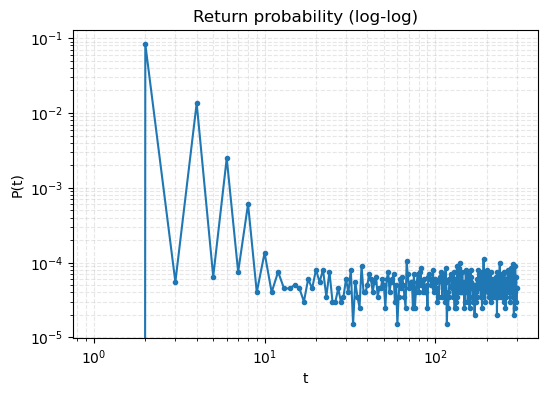

In [7]:
# Parameters (tune as needed)
num_steps = 300          # max steps
num_walkers = 200_000    # number of walkers

P_t = random_walk_return_prob(neighbor_tensor, degree_tensor, num_steps, num_walkers)

t_vals = np.arange(num_steps + 1)

plt.figure(figsize=(6,4))
plt.loglog(t_vals[1:], P_t[1:], 'o-', markersize=3)
plt.xlabel('t')
plt.ylabel('P(t)')
plt.title('Return probability (log-log)')
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.show()

## 5. Fit slope on a chosen window to estimate $d_s$

Pick a window `[t_min, t_max]` where the curve looks approximately linear on the log-log plot.

We fit:

$$ \log P(t) \approx -\frac{d_s}{2} \log t + C. $$

So the slope `m` gives `d_s = -2 m`.

You can adjust the window and see how stable the estimate is.

Fit window [20, 150] -> d_s = -0.019, R^2 = 0.0002


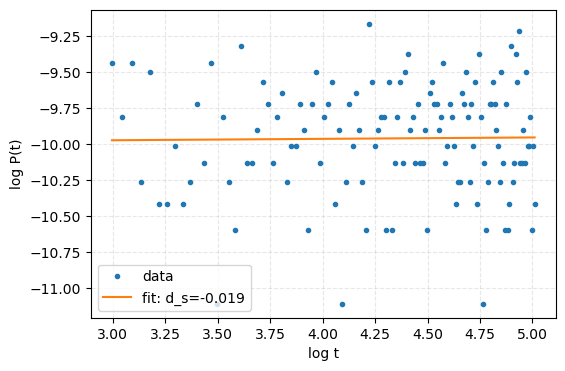

In [8]:
def fit_spectral_dimension(t_vals, P_t, t_min, t_max):
    mask = (t_vals >= t_min) & (t_vals <= t_max) & (P_t > 0)
    x = np.log(t_vals[mask])
    y = np.log(P_t[mask])
    A = np.vstack([x, np.ones_like(x)]).T
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    d_s = -2 * m
    # R^2
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    return d_s, m, b, r2

# Example window (tune by eye after seeing the plot)
t_min, t_max = 20, 150
d_s, m, b, r2 = fit_spectral_dimension(t_vals, P_t, t_min, t_max)
print(f"Fit window [{t_min}, {t_max}] -> d_s = {d_s:.3f}, R^2 = {r2:.4f}")

# Plot with fit line
mask = (t_vals >= t_min) & (t_vals <= t_max) & (P_t > 0)
x = np.log(t_vals[mask])
y = np.log(P_t[mask])
y_pred = m * x + b

plt.figure(figsize=(6,4))
plt.plot(x, y, 'o', label='data', markersize=3)
plt.plot(x, y_pred, '-', label=f'fit: d_s={d_s:.3f}')
plt.xlabel('log t')
plt.ylabel('log P(t)')
plt.legend()
plt.grid(True, ls='--', alpha=0.3)
plt.show()

## 6. How this connects back to CPP / SM-8 / SM-9

- With the **synthetic 12-regular graph**, you get a baseline sense of what a generic 12-regular cage-like lattice does.
- Once you replace it with a **true tiled 600-cell cage lattice** (as `tiled600_edgelist.txt`),
  the same notebook will give you a numerical estimate of the asymptotic spectral dimension of the CPP confinement geometry.

For the CPP story, you’re watching to see whether the stable intermediate-scale slope clusters near:

$$ d_s \approx 3 - \frac{1}{\varphi} \approx 2.382. $$

That’s the number that would make the spectral-dimension route to $\alpha$ feel deeply non-coincidental.